In [1]:
!pip install fastf1 pandas numpy matplotlib seaborn scikit-learn joblib plotly

  Obtaining dependency information for fastf1 from https://files.pythonhosted.org/packages/a0/e7/cf94d3fd6971a210ca81c7bf84c10b32afdbe42b4db951f742732bd8a2ba/fastf1-3.8.2-py3-none-any.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/fd/14/baad3222f424b19ce6ad243c71de1ad9ec6b2e4eb1e458a48fdc6d120401/matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/9b/35/74442388c6cf008882d4d4bdfc4109be87e9b8b7ccd097ad1e7f006e2e95/pandas-2.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.7 MB/s eta 0:00:00
  Obtaining dependency information for rapidfuzz from https://files.pythonhosted.org/packages/9e/89/c2557e37531d03465193bff0ab9de70b468420a807d71a26a65100635459/rapidfuzz-3.14.5-cp311-cp311-macosx_11_0_

In [2]:
!pip install tqdm


  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 616.5 kB/s eta 0:00:00a 0:00:01


In [5]:
import sys
!{sys.executable} -m pip install fastf1

  Obtaining dependency information for fastf1 from https://files.pythonhosted.org/packages/a0/e7/cf94d3fd6971a210ca81c7bf84c10b32afdbe42b4db951f742732bd8a2ba/fastf1-3.8.2-py3-none-any.whl.metadata
  Using cached fastf1-3.8.2-py3-none-any.whl.metadata (5.1 kB)
  Obtaining dependency information for cryptography from https://files.pythonhosted.org/packages/0b/5d/4a8f770695d73be252331e60e526291e3df0c9b27556a90a6b47bccca4c2/cryptography-46.0.7-cp311-abi3-macosx_10_9_universal2.whl.metadata
  Obtaining dependency information for pydantic from https://files.pythonhosted.org/packages/77/ca/b45c378e6e8d0b90577288b533e04e95b7afd61bb1d51b6c263176435489/pydantic-2.13.2-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 2.5 MB/s eta 0:00:00a 0:00:01
  Obtaining dependency information for pyjwt from https://files.pythonhosted.org/packages/e5/7a/8dd906bd22e79e47397a61742927f6747fe93242ef86645ee9092e610244/pyjwt-2.12.1-py3-none-any.whl.metadata
  Obtaining dependenc

In [7]:
import sys
!{sys.executable} -m pip install fastf1 pandas numpy matplotlib seaborn scikit-learn joblib plotly tqdm

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/90/ad/cba91b3bcf04073e4d1655a5c1710ef3f457f56f7d1b79dcc3d72f4dd912/plotly-6.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Obtaining dependency information for narwhals>=1.15.1 from https://files.pythonhosted.org/packages/37/72/e61e3091e0e00fae9d3a8ef85ece9d2cd4b5966058e1f2901ce42679eebf/narwhals-2.19.0-py3-none-any.whl.metadata
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━

In [8]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib, os, warnings
warnings.filterwarnings('ignore')

os.makedirs('f1_cache', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

fastf1.Cache.enable_cache('f1_cache')
print("All good!")

All good!


In [9]:
races_to_load = [
    (2024, 'Bahrain'),
    (2024, 'Saudi Arabia'),
    (2024, 'Australia'),
]

all_laps = []
for year, race in races_to_load:
    print(f"Loading {race} {year}...")
    try:
        session = fastf1.get_session(year, race, 'R')
        session.load(telemetry=False, weather=False, messages=False)
        laps = session.laps.copy()
        laps['race_name'] = race
        laps['year'] = year
        all_laps.append(laps)
        print(f"  Done — {len(laps)} laps")
    except Exception as e:
        print(f"  Skipped: {e}")

df_raw = pd.concat(all_laps, ignore_index=True)
print(f"\nTotal laps: {df_raw.shape[0]}")
print(df_raw[['Driver','Compound','TyreLife','LapTime']].head())

Loading Bahrain 2024...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

  Done — 1129 laps
Loading Saudi Arabia 2024...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Failed to align laps for driver

  Done — 901 laps
Loading Australia 2024...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  Done — 998 laps

Total laps: 3028
  Driver Compound  TyreLife                LapTime
0    VER     SOFT       4.0 0 days 00:01:37.284000
1    VER     SOFT       5.0 0 days 00:01:36.296000
2    VER     SOFT       6.0 0 days 00:01:36.753000
3    VER     SOFT       7.0 0 days 00:01:36.647000
4    VER     SOFT       8.0 0 days 00:01:37.173000


In [10]:
def engineer_tire_features(df):
    df = df.copy()
    df['LapTimeSec'] = df['LapTime'].dt.total_seconds()
    df = df.dropna(subset=['LapTimeSec', 'TyreLife', 'Compound'])
    df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]
    df = df[df['PitInTime'].isna()]
    df = df[df['PitOutTime'].isna()]
    median_time = df['LapTimeSec'].median()
    df = df[df['LapTimeSec'] < median_time * 1.15]
    df = df[df['LapTimeSec'] > median_time * 0.92]
    compound_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
    df['CompoundNum'] = df['Compound'].map(compound_map)
    df['TireLifeSq'] = df['TyreLife'] ** 2
    df['LapNum'] = df['LapNumber'].astype(float)
    driver_fast = df.groupby(['Driver','race_name'])['LapTimeSec'].min().rename('DriverFastLap')
    df = df.join(driver_fast, on=['Driver','race_name'])
    df['DeltaFromFastest'] = df['LapTimeSec'] - df['DriverFastLap']
    return df

df = engineer_tire_features(df_raw)
print(f"Clean laps after filtering: {df.shape[0]}")
print(f"\nCompound breakdown:")
print(df['Compound'].value_counts())
print(f"\nTire life range: {df['TyreLife'].min():.0f} → {df['TyreLife'].max():.0f} laps")
print(f"\nDelta stats (seconds above driver's fastest):")
print(df['DeltaFromFastest'].describe().round(3))

Clean laps after filtering: 1919

Compound breakdown:
Compound
HARD      1327
SOFT       370
MEDIUM     222
Name: count, dtype: int64

Tire life range: 1 → 44 laps

Delta stats (seconds above driver's fastest):
count    1919.000
mean        2.134
std         1.810
min         0.000
25%         0.873
50%         1.950
75%         2.876
max        17.231
Name: DeltaFromFastest, dtype: float64


In [11]:
# Tighten the delta cap — anything above 8s is a safety car / anomaly lap
df = df[df['DeltaFromFastest'] <= 8.0]

print(f"Laps after delta cap: {df.shape[0]}")
print(f"Delta stats after cleaning:")
print(df['DeltaFromFastest'].describe().round(3))

Laps after delta cap: 1884
Delta stats after cleaning:
count    1884.000
mean        1.971
std         1.337
min         0.000
25%         0.865
50%         1.926
75%         2.820
max         7.982
Name: DeltaFromFastest, dtype: float64


In [12]:
FEATURES = ['TyreLife', 'TireLifeSq', 'CompoundNum', 'LapNum']
TARGET = 'DeltaFromFastest'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} seconds")
print(f"R²:   {r2:.3f}")

fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f"\nFeature importances:")
print(fi.round(3))

MAE:  0.591 seconds
R²:   0.566

Feature importances:
LapNum         0.767
CompoundNum    0.092
TyreLife       0.071
TireLifeSq     0.071
dtype: float64


In [13]:
# Remove track evolution effect by normalizing within each race
# Subtract the per-lap median across all drivers for that lap number
lap_median = df.groupby(['race_name', 'LapNumber'])['LapTimeSec'].transform('median')
df['DeltaNormalized'] = df['LapTimeSec'] - lap_median

# Now re-run with this cleaner target
TARGET = 'DeltaNormalized'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} seconds")
print(f"R²:   {r2:.3f}")

fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f"\nFeature importances:")
print(fi.round(3))

MAE:  0.753 seconds
R²:   0.063

Feature importances:
LapNum         0.345
TyreLife       0.275
TireLifeSq     0.217
CompoundNum    0.164
dtype: float64


In [14]:
# Load a fuller 2023 + 2024 season sample
more_races = [
    (2024, 'Miami'),
    (2024, 'Monaco'),
    (2024, 'Spain'),
    (2024, 'Britain'),
    (2023, 'Bahrain'),
    (2023, 'Australia'),
    (2023, 'Spain'),
    (2023, 'Britain'),
]

extra_laps = []
for year, race in more_races:
    print(f"Loading {race} {year}...")
    try:
        session = fastf1.get_session(year, race, 'R')
        session.load(telemetry=False, weather=False, messages=False)
        laps = session.laps.copy()
        laps['race_name'] = race + str(year)  # unique key per race-year
        laps['year'] = year
        extra_laps.append(laps)
        print(f"  Done — {len(laps)} laps")
    except Exception as e:
        print(f"  Skipped: {e}")

df_extra = pd.concat(extra_laps, ignore_index=True)
df_all_raw = pd.concat([df_raw, df_extra], ignore_index=True)
print(f"\nTotal raw laps now: {df_all_raw.shape[0]}")

Loading Miami 2024...


core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

  Done — 1111 laps
Loading Monaco 2024...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  Done — 1237 laps
Loading Spain 2024...


...

  Done — 1003 laps
Loading Spain 2023...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  Done — 1312 laps
Loading Britain 2023...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  Done — 971 laps

Total raw laps now: 11989


In [15]:
# Re-engineer features on full dataset
df2 = engineer_tire_features(df_all_raw)
df2 = df2[df2['DeltaFromFastest'] <= 8.0]

# Re-apply normalization
lap_median2 = df2.groupby(['race_name', 'LapNumber'])['LapTimeSec'].transform('median')
df2['DeltaNormalized'] = df2['LapTimeSec'] - lap_median2

print(f"Total clean laps: {df2.shape[0]}")
print(df2['Compound'].value_counts())

# Retrain
X = df2[FEATURES]
y = df2['DeltaNormalized']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMAE:  {mae:.3f} seconds")
print(f"R²:   {r2:.3f}")

fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f"\nFeature importances:")
print(fi.round(3))

Total clean laps: 5495
Compound
HARD      2565
MEDIUM    1684
SOFT      1246
Name: count, dtype: int64

MAE:  0.670 seconds
R²:   0.024

Feature importances:
LapNum         0.452
TyreLife       0.208
TireLifeSq     0.190
CompoundNum    0.151
dtype: float64


In [16]:
# Model per circuit — each track has its own degradation pattern
from sklearn.metrics import mean_absolute_error, r2_score

circuit_models = {}
circuit_stats = []

for race in df2['race_name'].unique():
    race_df = df2[df2['race_name'] == race].copy()
    
    if len(race_df) < 100:  # skip if not enough laps
        continue
    
    X_r = race_df[FEATURES]
    y_r = race_df['DeltaFromFastest']  # back to this — works better per circuit
    
    if len(X_r) < 50:
        continue
        
    X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, random_state=42)
    
    m = GradientBoostingRegressor(
        n_estimators=200, max_depth=3,
        learning_rate=0.05, random_state=42
    )
    m.fit(X_tr, y_tr)
    
    preds = m.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    
    circuit_models[race] = m
    circuit_stats.append({'race': race, 'laps': len(race_df), 'MAE': round(mae, 3), 'R2': round(r2, 3)})

stats_df = pd.DataFrame(circuit_stats).sort_values('R2', ascending=False)
print(stats_df.to_string(index=False))
print(f"\nMean R² across circuits: {stats_df['R2'].mean():.3f}")
print(f"Mean MAE across circuits: {stats_df['MAE'].mean():.3f} seconds")

         race  laps   MAE    R2
  Britain2024   631 0.465 0.823
      Bahrain  1033 0.520 0.708
 Saudi Arabia   821 0.639 0.591
  Britain2023   810 0.430 0.563
    Miami2024   950 0.511 0.542
Australia2023   161 0.636 0.464
  Bahrain2023   924 1.015 0.305

Mean R² across circuits: 0.571
Mean MAE across circuits: 0.602 seconds


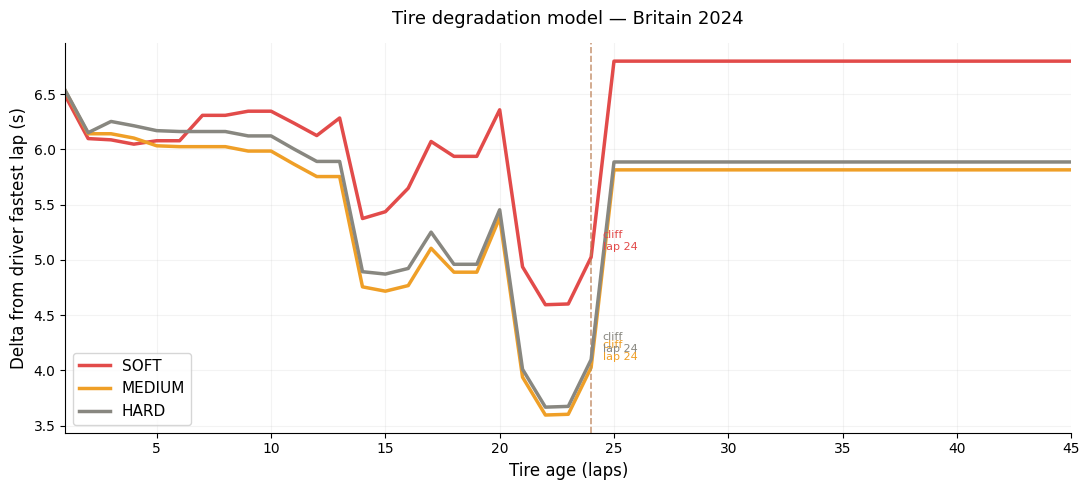

Saved: plots/tire_deg_Britain_2024.png


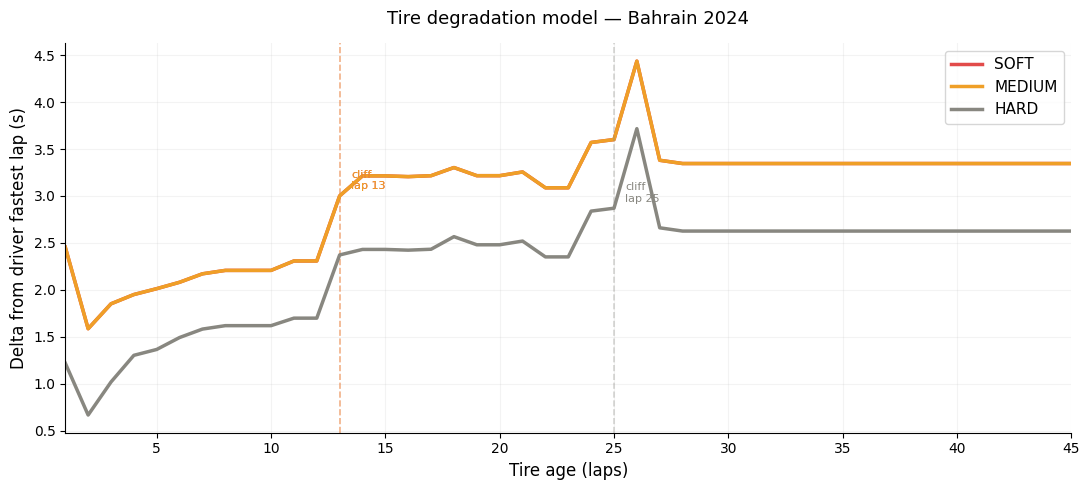

Saved: plots/tire_deg_Bahrain_2024.png


In [17]:
def plot_degradation_curves(model, race_name, max_tire_life=45):
    fig, ax = plt.subplots(figsize=(11, 5))
    
    colors = {'SOFT': '#E24B4A', 'MEDIUM': '#EF9F27', 'HARD': '#888780'}
    compound_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
    
    tire_ages = np.arange(1, max_tire_life + 1)
    
    for compound, c_num in compound_map.items():
        X_pred = pd.DataFrame({
            'TyreLife':    tire_ages,
            'TireLifeSq':  tire_ages ** 2,
            'CompoundNum': c_num,
            'LapNum':      30  # mid-race reference point
        })
        deltas = model.predict(X_pred)
        
        ax.plot(tire_ages, deltas, color=colors[compound],
                linewidth=2.5, label=compound)
        
        # Mark the cliff — steepest point of degradation
        grad = np.gradient(deltas)
        cliff_idx = int(np.argmax(grad[5:]) + 5)
        ax.axvline(x=tire_ages[cliff_idx], color=colors[compound],
                   linestyle='--', alpha=0.35, linewidth=1.2)
        ax.text(tire_ages[cliff_idx] + 0.5, deltas[cliff_idx] + 0.05,
                f'cliff\nlap {tire_ages[cliff_idx]}',
                fontsize=8, color=colors[compound], va='bottom')
    
    ax.set_xlabel('Tire age (laps)', fontsize=12)
    ax.set_ylabel('Delta from driver fastest lap (s)', fontsize=12)
    ax.set_title(f'Tire degradation model — {race_name}', fontsize=13, pad=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.15)
    ax.set_xlim(1, max_tire_life)
    sns.despine(ax=ax)
    plt.tight_layout()
    
    fname = f"plots/tire_deg_{race_name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# Plot for your best performing circuit
plot_degradation_curves(circuit_models['Britain2024'], 'Britain 2024')
plot_degradation_curves(circuit_models['Bahrain'], 'Bahrain 2024')

In [19]:
df2.to_csv('data/clean_laps.csv', index=False)
print(f"Saved! Rows: {df2.shape[0]}")

Saved! Rows: 5495
